<a href="https://colab.research.google.com/github/YuliiaDina/transformer-survival-competing-risks-bachelor/blob/main/main_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Завантаження бібліотек

In [ ]:
import sys
import os

GITHUB_USER = "YuliiaDina"
REPO_NAME = "transformer-survival-competing-risks-bachelor"
REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"


if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}
else:
    %cd {REPO_NAME}
    !git pull origin main
    %cd ..

%cd {REPO_NAME}
PROJECT_PATH = os.path.abspath(".")

if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

!pip install -q scikit-survival comprisk
!pip install -q poetry
!poetry config virtualenvs.create false
!poetry install --no-root -q

/content/transformer-survival-competing-risks-bachelor/transformer-survival-competing-risks-bachelor
From https://github.com/YuliiaDina/transformer-survival-competing-risks-bachelor
 * branch            main       -> FETCH_HEAD
Already up to date.
/content/transformer-survival-competing-risks-bachelor
/content/transformer-survival-competing-risks-bachelor/transformer-survival-competing-risks-bachelor
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 3.7 MB/s eta 0:00:00


#Завантаження модулів нашого проекту з GitHub

In [ ]:
from src.data_prep import load_and_prepare_data, split_and_scale_data, create_time_bins, prepare_tensor_loaders, prepare_survival_data
from src.models import FinalTransformerModel
from src.baselines import train_cox_models, train_fine_gray_models
from src.engine import train_model_with_history
from src.metrics import compute_cox_cif
from src.visualization import plot_loss_curves, plot_cif_comparison,plot_calibration_curves_survival
from src.tables import build_table_1_demographics, build_table_2_metrics, build_table_3_hyperparams
from src.utils import run_cif_checks

print("Усі модулі успішно імпортовано")

Усі модулі успішно імпортовано


#Завантаження та обробка данних

In [ ]:
# 1. Завантаження датасету та розбиття на Train/Val/Test із масштабуванням ознак
df = load_and_prepare_data()
features = ['age', 'sex', 'dxyr', 'hgb', 'creat', 'mspike']
df_train, df_val, df_test, X_train_scaled, X_val_scaled, X_test_scaled = split_and_scale_data(df, features)

# 2. Квантилізація часу на 20 інтервалів та створення DataLoader для PyTorch
NUM_BINS = 20
bins = create_time_bins(df_train['time'].values, num_bins=NUM_BINS)
train_loader, val_loader, X_train_tensor, X_val_tensor, X_test_tensor = prepare_tensor_loaders(
    X_train_scaled, df_train, X_val_scaled, df_val, X_test_scaled, df_test, bins, batch_size=64
)

print("\n Дані оброблено, тензори та вибірки сформовано")


 Дані оброблено, тензори та вибірки сформовано


/content/transformer-survival-competing-risks-bachelor/src/data_prep.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_processed["sex"].replace({"F": 0, "M": 1}).astype(float)


#Навчання статичник моделей та транформетрів варіантів А та В

In [ ]:

print("\n Класичні статистичні базові моделі")
models_cox = train_cox_models(df_train, X_train_scaled)
models_fg = train_fine_gray_models(df_train, X_train_scaled)

print("\nTransformers")

# Навчання Варіанту А: Стандартна архітектура
model_A_hist, train_hist_A, val_hist_A = train_model_with_history(
    variant_name='A',
    train_loader=train_loader,
    val_loader=val_loader,
    n_features=6,
    num_bins=NUM_BINS,
    max_epochs=200,
    patience=15
)

# Навчання Варіанту В: Архітектура з монотонною увагою (Monotonic Attention)
model_B_hist, train_hist_B, val_hist_B = train_model_with_history(
    variant_name='B',
    train_loader=train_loader,
    val_loader=val_loader,
    n_features=6,
    num_bins=NUM_BINS,
    max_epochs=200,
    patience=15
)

print("\n Навчання моделей закінчено")


 Класичні статистичні базові моделі

[Baselines] Навчання Cause-specific Cox...
 Cox для Події 1 навчено.
 Cox для Події 2 навчено.

[Baselines] Навчання Fine-Gray (comprisk)...
Fine-Gray для Події 1 навчено.
Fine-Gray для Події 2 навчено.

Transformers

[Trainer] Запуск навчання для Variant A...
  Епоха [  1/200] | Train Loss: 5.0367 | Val Loss: 2.8566
  Епоха [ 10/200] | Train Loss: 2.6483 | Val Loss: 2.5135
  Епоха [ 20/200] | Train Loss: 2.5831 | Val Loss: 2.4783
  Епоха [ 30/200] | Train Loss: 2.5355 | Val Loss: 2.4734
  [-] Рання зупинка на епосі 36. Ваги найкращої епохи відновлено.

[Trainer] Запуск навчання для Variant B...
  Епоха [  1/200] | Train Loss: 7.2400 | Val Loss: 3.2822
  Епоха [ 10/200] | Train Loss: 2.6242 | Val Loss: 2.5081
  Епоха [ 20/200] | Train Loss: 2.5869 | Val Loss: 2.5089
  [-] Рання зупинка на епосі 24. Ваги найкращої епохи відновлено.

 Навчання моделей закінчено


#Валідація данних та графічна візуалізація отриманих результатів


Перевірка для Variant A (Стандартний):
 1. Невід'ємність: всі значення CIF >= 0
 2. Монотонність: CIF не спадає з часом
 3. Обмеження суми: сума за причинами <= 1
 [i] Сума CIF на останньому інтервалі: середнє=0.8290, min=0.3171, max=1.0000
  -> Це означає, що середня ймовірність пацієнта вижити без жодної події S(t) до кінця дослідження складає 17.1%

Перевірка для Variant B (Monotonic):
 1. Невід'ємність: всі значення CIF >= 0
 2. Монотонність: CIF не спадає з часом
 3. Обмеження суми: сума за причинами <= 1
 [i] Сума CIF на останньому інтервалі: середнє=0.8316, min=0.3820, max=1.0000
  -> Це означає, що середня ймовірність пацієнта вижити без жодної події S(t) до кінця дослідження складає 16.8%


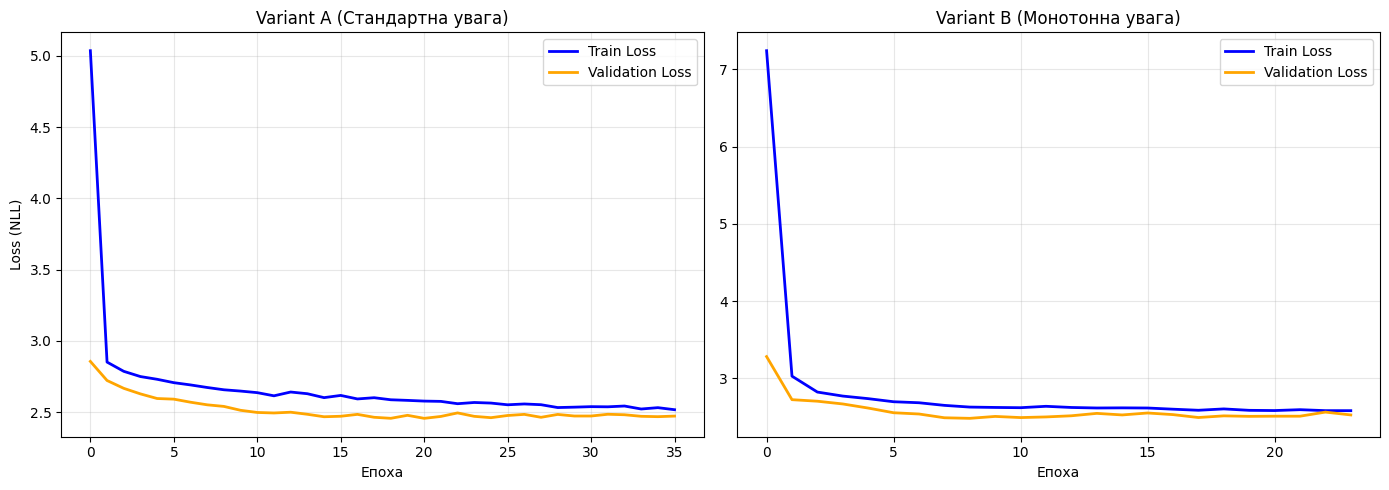

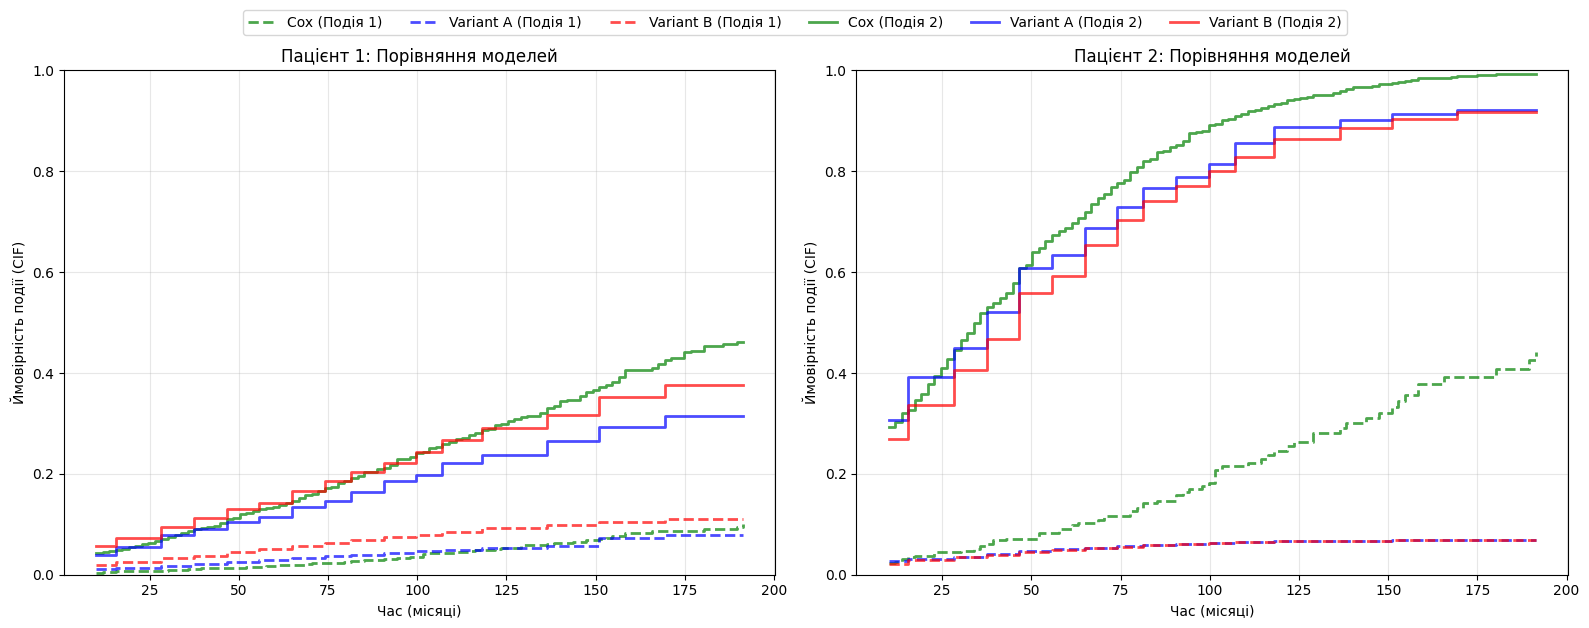

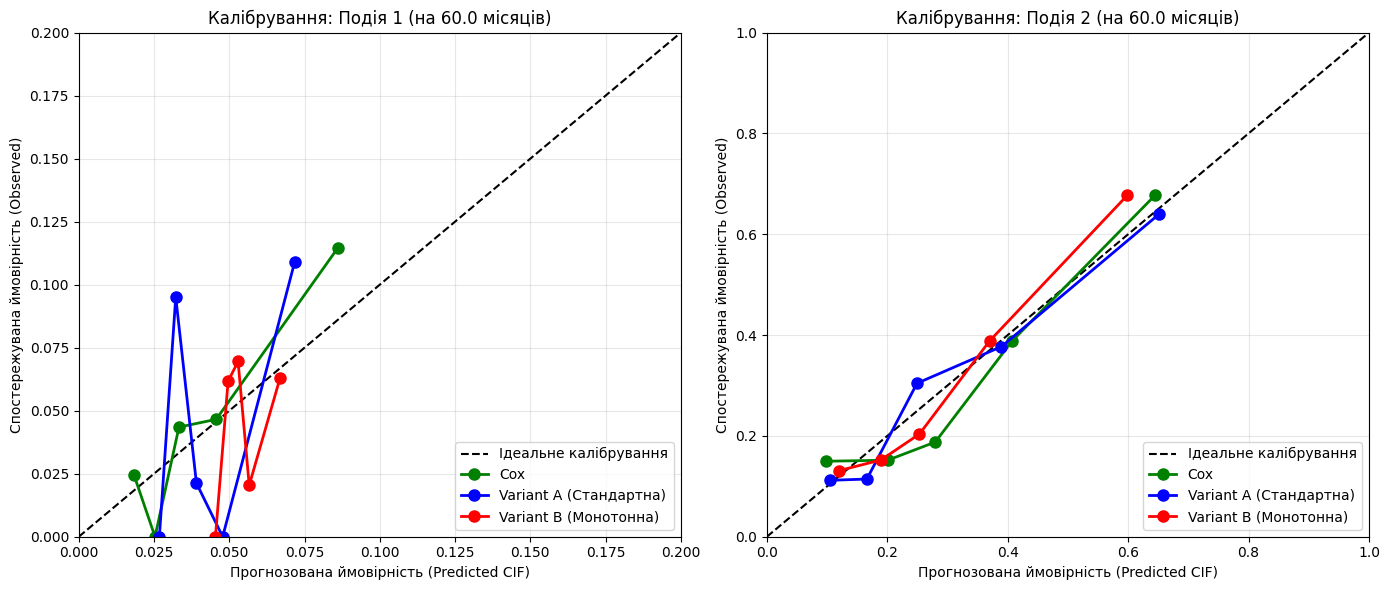


 Валідаційні тести пройдено, графіки побудовано!


In [ ]:
import numpy as np

# 1. Верифікація математичної коректності функцій інцидентності
run_cif_checks(model_A_hist, 'A (Стандартний)', X_test_tensor)
run_cif_checks(model_B_hist, 'B (Monotonic)', X_test_tensor)

# 2. Графіки збіжності кривих навчання (Loss Curves)
plot_loss_curves(train_hist_A, val_hist_A, train_hist_B, val_hist_B)

# 3. Побудова порівняльних графіків функцій CIF
min_time = np.percentile(df_test['time'], 10)
max_time = np.percentile(df_test['time'], 90)
brier_times = np.linspace(min_time, max_time, 100)

plot_cif_comparison(models_cox, model_A_hist, model_B_hist, X_test_scaled, X_test_tensor, brier_times, bins)

# 4. Побудова графіків калібрування (на горизонт 5 років / 60 місяців)
plot_calibration_curves_survival(
    models_cox,model_A_hist,model_B_hist,X_test_scaled,X_test_tensor,df_test,bins,
    target_time=60.0,max_limits={1: 0.2, 2: 1.0}
)
print("\n Валідаційні тести пройдено, графіки побудовано!")

#Зображення отриманих метрик та данних у вигляді таблиць

In [ ]:
from IPython.display import display
# таблиця описової статистики вибірки
df_table1 = build_table_1_demographics(df)
# Виводимо без індексів, з вирівнюванням тексту по лівому краю для зручності читання
display(df_table1.style.hide(axis="index").set_properties(**{'text-align': 'left'}))

# таблиця метрик
print("\n\n\033[4m ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ МЕТРИК \033[0m\n")

times_to_evaluate = np.array([24, 60, 120])
min_time = np.percentile(df_test['time'], 10)
max_time = np.percentile(df_test['time'], 90)
brier_times = np.linspace(min_time, max_time, 100)

df_metrics = build_table_2_metrics(
    models_cox=models_cox,
    models_fg_python=models_fg, # словник FG
    model_A_hist=model_A_hist,
    model_B_hist=model_B_hist,
    df_train=df_train,
    df_test=df_test,
    X_test_scaled=X_test_scaled,
    X_test_tensor=X_test_tensor,
    bins=bins,
    brier_times=brier_times,
    times_to_evaluate=times_to_evaluate
)
display(df_metrics.style.set_properties(**{'text-align': 'center'}))


# таблиця гіперпараметрів
print("\n\n\033[4m ТАБЛИЦЯ ГІПЕРПАРАМЕТРІВ \033[0m\n")

df_hyperparams = build_table_3_hyperparams(
    model_instance=model_A_hist,
    batch_size=64,
    lr=0.001,
    num_bins=NUM_BINS,
    patience=15
)
display(df_hyperparams.style.hide(axis="index").set_properties(**{'text-align': 'left'}))

Клінічна характеристика,Значення
AGE,70.42 ± 12.17
DXYR,1983.50 ± 6.37
HGB,13.30 ± 2.02
CREAT,1.29 ± 1.12
MSPIKE,1.16 ± 0.57
Стать 'M',753 (54.4%)
Стать 'F',631 (45.6%)
Подія: 0 (Цензуровано),409 (29.6%)
Подія: 1 (Прогресія),115 (8.3%)
Подія: 2 (Смерть),860 (62.1%)




 ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ МЕТРИК 



,Model,Event,C-index,IBS,AUC 2yr,AUC 5yr,AUC 10yr
0,Cox,1,0.692800,0.071600,0.766900,0.727900,0.672000
1,Fine-Gray,1,0.610900,0.073400,0.626400,0.599000,0.593100
2,Transformer A,1,0.610400,0.071800,0.702700,0.617100,0.643800
3,Transformer B,1,0.443600,0.074600,0.585900,0.543600,0.506100
4,Cox,2,0.720500,0.162400,0.691400,0.735100,0.815500
5,Fine-Gray,2,0.719100,0.163900,0.690700,0.733900,0.810100
6,Transformer A,2,0.715700,0.158500,0.756000,0.756600,0.813200
7,Transformer B,2,0.719300,0.162100,0.715000,0.747400,0.815000




 ТАБЛИЦЯ ГІПЕРПАРАМЕТРІВ 



Гіперпараметр,Значення,Опис (Призначення)
d_model,32,Розмірність векторних ембедингів (feature projection)
n_heads,2,Кількість голів у механізмі уваги (Multi-head Attention)
num_layers,2,Кількість шарів енкодера Трансформера
T (Time Bins),20,Кількість дискретних часових кошиків (за квантилями)
Batch Size,64,Розмір пакету для навчання моделі
Learning Rate,0.001000,Швидкість навчання оптимізатора
Early Stopping Patience,15,Епох без покращення валідаційної помилки до зупинки
Optimizer,Adam,Алгоритм оптимізації ваг нейромережі
